# 1. http请求详解

HTTP（HyperText Transfer Protocol，超文本传输协议）是互联网上应用最为广泛的一种网络协议。可以把它理解成网络世界交流的语言的一种（就像众多语言中，最通用的是英语一样）。

普通的 HTTP 协议是明文传输数据，过程中的所有人都能看到你在传什么，所以又提出了 **HTTPS**（HyperText Transfer Protocol Secure，安全超文本传输协议）。HTTPS 在 HTTP 和传输层之间加入 TLS/SSL 加密层，保护数据传输的安全性和完整性。

HTTP 协议规定了客户端和服务器通信时必须遵循的 **"请求（request）- 响应（response）模型"**。

现在我们来拆解 HTTP 请求和响应过程中涉及的各要素。

## 1.1 URL

URL（统一资源定位符，Uniform Resource Locator）用来定位服务器和服务。显然你要向服务器发送请求，你先得知道服务器和对应服务在哪。

以和风天气为例：
```
https://abcxyz.qweatherapi.com:443/airquality/v1/station/{LocationID}?lang=en
\___/   \____________________/\__/\____________________/\___________/\______/
scheme          host          port        path            path        query
                                                         params       params 
```
其中：
- **scheme**：协议，在这里只会是 `http` 或 `https`，在其他网络活动时还可能是 `ftp`（文件传输协议）、`ws`（WebSocket 协议）等。
- **host**：域名，标识服务器地址，将通过 DNS 服务商解析为 IP 地址，在部分情况下也会直接使用 IP 地址而不是域名。
- **port**：端口，一台服务器上可以运行很多服务（比如网页服务、数据库服务、文件传输服务），它们通过不同的端口来区分。可省略，HTTP 默认端口 80，HTTPS 默认端口 443。
- **path**：资源路径。指向服务器上的具体服务接口或文件位置，用于区分服务器上的不同功能。
- **path params**：路径参数，直接嵌入 URL，实际上是 path 的一部分，如有则必选。
- **query params**：查询参数，用 `?` 开头，多个查询参数使用 `&` 分割，包含必选参数和可选参数。

**小练习：**

当前教程就是通过 HTTP 打开的 Jupyter Notebook，尝试解析该url的组成：
```
http://localhost:8888/notebooks/xxxx.ipynb
```
<details>
<summary style="cursor:pointer; font-size:12px; font-weight:bold;">答案（点击展开）</summary>
<pre>
    http://localhost:8888/notebooks/xxxx.ipynb
    \___/  \_______/\___/\__________________/
    scheme   host    port        path 
</pre>
</pre>

</details>
<br/>
尝试解析该url的组成：

```
https://api-docs.deepseek.com/guides/json_mode
```
<details>
<summary style="cursor:pointer; font-size:12px; font-weight:bold;">答案（点击展开）</summary>
<pre>
    https://api-docs.deepseek.com/guides/json_mode
    \____/  \___________________/\_______________/
    scheme         host               path 
</pre>
</pre>

## 1.2 请求方式(method)

HTTP 请求方法用来表明你想对服务器上的资源**做什么操作**。常见的方法有：

| 方法     | 作用                                   | 是否幂等       |
| -------- | ---------------------                   | ---------- |
| `GET`    | 获取资源（如查询天气、查询用户信息）       | 是          |
| `POST`   | 创建资源（如提交表单、调用大模型生成内容） | 否          |
| `PUT`    | 更新资源（整体替换）                     | 是          |
| `PATCH`  | 更新资源（部分修改）                     | 通常否（视实现而定） |
| `DELETE` | 删除资源                                | 是          |

> **幂等性**：幂等指的是"同一个请求执行一次或多次，返回的结果相同"。

实际开发中，**GET 和 POST 是最常用的两种方法**：
#### 1.GET
用于获取资源，常使用查询参数，例如：`?location=101010100`

**特点：**
- 查询参数直接暴露在地址栏，可被用户看到甚至修改，会被记录在日志里，安全性较低
- 通常不带请求体
- 有长度限制（浏览器/服务器对 URL 长度有限制）
- 幂等：多次调用不会改变资源状态，返回结果一致

#### 2.POST
用于创建、提交资源

**特点：**
- 参数一般放在 body 中（也可以同时在 URL 上携带查询参数，但核心数据放 body）
- body 内容不会显示在地址栏，相对更安全
- 不幂等：多次调用可能重复创建或修改资源

## 1.3 请求结构和响应结构

#### 1.请求结构

一个完整的 HTTP 请求通常由以下三部分组成：
<div align="center">
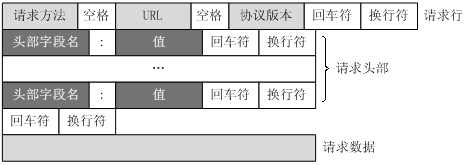
</div>

拆解：
1. **请求行**：`方法 + 路径(含query params) + HTTP版本`
2. **请求头（Headers）**：以 `键: 值` 形式提供附加信息，比如认证信息（`X-QW-Api-Key`）、希望接收的数据格式（`Accept`）、客户端类型(User-Agent)等
3. **请求体（Body）**：携带具体数据，GET 请求一般不带请求体，POST/PUT 等请求常用 JSON 格式请求体

GET示例：
```http
GET /v7/weather/now?location=101010100 HTTP/1.1
Host: devapi.qweather.com
X-QW-Api-Key: xxxxxxxxxxxxxxxxxxxxxxxxxxx
Accept: application/json
```
POST示例：
```http
POST /v1/chat/completions HTTP/1.1
Host: api.example.com
Content-Type: application/json
Authorization: Bearer sk-xxxxxxxxxxxxxxxx 

{
"model": "some-model",
"messages": [{"role": "user", "content": "你好，介绍一下你自己"}],
"max_tokens": 100
}

```

#### 2.响应结构
服务器收到请求后，会返回一个 HTTP 响应，结构上和请求类似：
```html
HTTP/1.1 200 OK
Content-Type: application/json; charset=utf-8
Content-Length: 256

{"code": "200", "now": {"temp": "26", "text": "雾"}}
```
拆解：
1. **状态行**：`HTTP版本 + 状态码 + 状态描述`。状态码表示请求的处理结果，如 200 表示成功，404 表示未找到资源,可通过response.status_code查看。状态描述就是状态码的简短描述。
2. **响应头（Headers）**：说明返回内容的类型（`Content-Type`）、长度（`Content-Length`）、缓存策略等。可通过response.headers查看
3. **响应体（Body）**：服务器返回的数据内容，通常是 JSON、HTML 或其他格式。可通过response.text查看


In [3]:
#通过千帆平台get模型列表的示例
#千帆平台文档 https://cloud.baidu.com/doc/qianfan-api/s/Dmba8k71y
import requests
import json

from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.environ.get("QIANFAN_API_KEY")

headers={
    'Content-Type': 'application/json', #表示我发送的数据是什么格式，get请求其实一般不用
    'Authorization': f'Bearer {api_key}'
}
response=requests.get('https://qianfan.baidubce.com/v2/models',headers=headers)
model_list=[i['id'] for i in response.json()['data']]
print(model_list[:5]) #打印前5条

['ernie-4.5-turbo-vl', 'ernie-4.5-turbo-vl-32k', 'ernie-image-turbo', 'deepseek-r1-distill-qwen-32b', 'ernie-4.5-0.3b']


In [5]:
#通过千帆平台post大模型对话的示例
payload = json.dumps({
        "model": "deepseek-r1-distill-qwen-14b",
        "messages": [
            {
                "role": "system",
                "content": "You are a helpful assistant."
            },
            {
                "role": "user",
                "content": "你好"
            }
        ]
    })
response=requests.post("https://qianfan.baidubce.com/v2/chat/completions",headers=headers,data=payload)
print(response.json())

{'id': 'as-h9ecmnnmg7', 'object': 'chat.completion', 'created': 1782268704, 'model': 'deepseek-r1-distill-qwen-14b', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '\n\n你好！有什么我可以帮助你的吗？', 'reasoning_content': 'Alright, the user just said "你好," which means "hello" in Chinese. I should respond warmly.\n\nI want to make them feel welcome and offer my help.\n\nMaybe I\'ll ask how I can assist them today.\n\nKeeping it friendly and open-ended should work well.\n'}, 'finish_reason': 'stop', 'flag': 0}], 'usage': {'prompt_tokens': 12, 'completion_tokens': 66, 'total_tokens': 78, 'completion_tokens_details': {'reasoning_tokens': 55}}}


In [6]:
print(response.status_code)

200


In [7]:
print(response.json()['choices'][0]['message']['content'])



你好！有什么我可以帮助你的吗？


## 3.4. 状态码

状态码(http status code)是服务器告诉客户端"这次请求处理得怎么样"的三位数字代码，第一位数字表示大类：

| 类别 | 含义 | 常见示例 |
|------|------|----------|
| `1xx` | 表示请求已接收，正在处理 | `101 Switching Protocols` |
| `2xx` | 表示正常处理完毕 | `200 OK`（成功）、`201 Created`（创建成功） |
| `3xx` | 重定向，需要进一步操作才能完成请求 | `301 Moved Permanently`（永久重定向）、`304 Not Modified`（资源未修改，可用缓存） |
| `4xx` | 客户端错误，请求本身有误 | `400 Bad Request`（请求参数错误）、`401 Unauthorized`（未认证）、`403 Forbidden`（无权限）、`404 Not Found`（资源不存在） |
| `5xx` | 服务器错误 | `500 Internal Server Error`（服务器内部错误）、`503 Service Unavailable`（服务暂不可用） |

比较常见的是2xx\4xx\5xx

## 3.5. HTTP 的关键特性

1. **无状态（Stateless）**
   服务器不会记住你上一次的请求。每次请求都是独立的，服务器仅根据本次请求的内容处理，不依赖之前的交互历史。
   → 这也是为什么很多服务需要你**每次请求都带上 API Key 或 Token** 来证明身份，而不是登录一次就一直记着你。

2. **请求-响应模型（Request-Response）**
   通信永远是"客户端发起请求，服务器返回响应"的一问一答模式，服务器不会主动联系客户端。
   → 如果需要服务器主动推送消息（比如实时聊天），就需要 WebSocket 等其他协议。

3. **可扩展性**
   通过自定义请求头（如 `X-QW-Api-Key`）可以灵活扩展 HTTP 的能力，这也是为什么几乎所有 API 服务都基于 HTTP/HTTPS 构建——协议本身简单、通用，又足够灵活。

## 3.6 Content-Type（在请求体传递不同类型的数据）

在传输不同类型数据时需要在请求头headers内指定不同的Content-Type，告诉服务器自己发送的是什么类型数据，常用的Content-Type如下
| Content-Type | 说明 | 典型场景 |
|---|---|---|
| `application/x-www-form-urlencoded` | 传字典/键值对 | 传统 HTML 表单提交（不含文件） |
| `multipart/form-data` | 传文件，同时也支持携带普通字段 | 文件上传 |
| `application/json` | 传JSON 格式的结构化文本 | API 接口传参，目前最常用的格式 |
| `text/plain` | 传纯文本 | 简单文本传输，无需结构化数据时 |

可以通过httpbin.org（一个专门用于测试 HTTP 请求的免费服务网站，会原样返回你发送的内容）来测试这几种格式

In [8]:
#传字典，application/x-www-form-urlencoded（表单格式）是html<form>元素提交数据的默认编码方式
import requests

url = "https://httpbingo.org/post"
data = {"name": "Alice", "age": 20}

response = requests.post(url, data=data) #使用data参数，请求头默认为 Content-Type: application/x-www-form-urlencoded
print(response.status_code)
print(response.json())  #可看到响应中，form关键字有我们传过去的内容

200
{'args': {}, 'data': '', 'files': {}, 'form': {'age': '20', 'name': 'Alice'}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '17', 'Content-Type': 'application/x-www-form-urlencoded', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-6a3b4429-384d50ff3f22d32728cfe191'}, 'json': None, 'origin': '103.62.49.170', 'url': 'https://httpbin.org/post'}


In [9]:
#传文件，multipart/form-data
import os,shutil
# 创建一个临时文件用于测试
with open("test.txt", "w") as f:
    f.write("这是测试文件内容")
with open("test.txt", "rb") as f:
    url = "https://httpbin.org/post"
    files = {"file": f}
    data = {"description": "测试上传"}
    
    response = requests.post(url, files=files, data=data) #可同时传其他参数
    print(response.status_code)
    print(response.json()) #可看到响应中，files关键字有内容

try:
    os.remove('test.txt') #删除测试文件
except:
    pass

200
{'args': {}, 'data': '', 'files': {'file': 'data:application/octet-stream;base64,1eLKx7LiytTOxLz+xNrI3Q=='}, 'form': {'description': '测试上传'}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '264', 'Content-Type': 'multipart/form-data; boundary=5489d53aced5a4650dde54bff6ce1610', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-6a3b442a-60c472b072f975910dc72a66'}, 'json': None, 'origin': '103.62.49.170', 'url': 'https://httpbin.org/post'}


In [10]:
#传json格式文本，application/json
url = "https://httpbin.org/post"
data = {"name": "Alice", "tags": ["VIP", "新用户"]}

# response = requests.post(url, json=data) # 使用json=data或data=json.dumps(data)
response = requests.post(url, data=json.dumps(data)) 
print(response.status_code)
print(response.json())  #可看到响应中，data关键字有内容

200
{'args': {}, 'data': '{"name": "Alice", "tags": ["VIP", "\\u65b0\\u7528\\u6237"]}', 'files': {}, 'form': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '56', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-6a3b4431-4769727a57e29dc2070c8523'}, 'json': {'name': 'Alice', 'tags': ['VIP', '新用户']}, 'origin': '103.62.49.170', 'url': 'https://httpbin.org/post'}


In [11]:
#传纯文本,text/plain
url = "https://httpbin.org/post"
text_data = "这是一条纯文本日志信息"

response = requests.post(
    url,
    data=text_data.encode("utf-8"),
    headers={"Content-Type": "text/plain; charset=utf-8"}
)
print(response.status_code)
print(response.json()) #可看到响应中，data关键字有内容

200
{'args': {}, 'data': '这是一条纯文本日志信息', 'files': {}, 'form': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '33', 'Content-Type': 'text/plain; charset=utf-8', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-6a3b4434-18ea9c20241bcfae10c53fe8'}, 'json': None, 'origin': '103.62.49.170', 'url': 'https://httpbin.org/post'}


In [13]:
#传图片，基于base64编码并嵌套在json内
#base64可以将任意二进制数据转换为 仅包含 A-Z、a-z、0-9、+、/（和 = 作为填充）的文本字符串，由此可以把图片等二进制文件嵌入json、文本文档等。代价是体积增大约33%。
import base64,io
with open('../assets/images/905504.png','rb') as f:
    """
    f.read()           # 读图片的原始二进制数据
    base64.b64encode()  # 把二进制数据转成 base64 编码的字节串 b'iVBORw0KGgo...'
    .decode('utf-8')     # 把base64字节串按utf-8解码为普通 str 方便后续使用，否则使用时可能报错
    """
    img_base64=base64.b64encode(f.read()).decode('utf-8')
response=requests.post('https://httpbin.org/post',json={"image":img_base64})
print(response.json())

{'args': {}, 'data': '{"image": "..."}', 'files': {}, 'form': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '445773', 'Content-Type': 'application/json', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.5', 'X-Amzn-Trace-Id': 'Root=1-6a3b444f-2a642a724b7b269038ea8957'}, 'json': {'image': '...'}, 'origin': '103.62.49.170', 'url': 'https://httpbin.org/post'}


## 3.7 解析响应中不同类型的数据

服务器返回的响应同样带有 `Content-Type`，告诉我们响应体是什么格式。
对于不同类型的响应，也需要采取不同的解析方式。

常见的响应数据类型：

| 响应 Content-Type | 解析方法 | 典型场景 |
|---|---|---|
| `application/json` | `response.json()` | API 接口返回结构化数据 |
| `text/html` 或 `text/plain` | `response.text` | 网页内容、纯文本返回 |
| `image/png`、`image/jpeg` 等二进制 | `response.content` | 图片、文件下载 |
| 大文件 / 流式数据 | `response.iter_content()` | 大文件下载，避免一次性占满内存 |



In [14]:
#解析json结构化文本，application/json
#response.json
#注意：如果响应体不是合法的 JSON 格式，调用 `.json()` 会抛出 `json.decoder.JSONDecodeError`，可以先用 `response.text` 查看原始内容再排查。
import requests

response = requests.get("https://jsonplaceholder.typicode.com/posts/1")
print(response.status_code)

data = response.json()  # 自动解析成字典
print(type(data))
print(data["title"])
print(data["body"])

200
<class 'dict'>
sunt aut facere repellat provident occaecati excepturi optio reprehenderit
quia et suscipit
suscipit recusandae consequuntur expedita et cum
reprehenderit molestiae ut ut quas totam
nostrum rerum est autem sunt rem eveniet architecto


In [15]:
#解析网页内容、纯文本等，text/html、text/plain
# response.text
response = requests.get("https://httpbin.org/html")
print(response.status_code)
print(response.headers["Content-Type"])  # text/html; charset=utf-8

html_content = response.text  # 原始 HTML 字符串
print(html_content[:200])  # 打印前200个字符

200
text/html; charset=utf-8
<!DOCTYPE html>
<html>
  <head>
  </head>
  <body>
      <h1>Herman Melville - Moby-Dick</h1>

      <div>
        <p>
          Availing himself of the mild, summer-cool weather that now reigned in t


200
image/jpeg


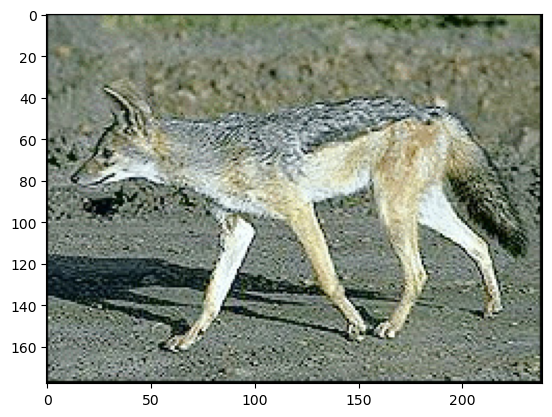

In [16]:
#解析二进制文件-bytes类型
#response.content 返回原始的字节数据（bytes 类型），适合图片、PDF、压缩包等二进制内容。
from PIL import Image
import io
import matplotlib.pyplot as plt
url = "https://httpbin.org/image/jpeg"
response = requests.get(url)
print(response.status_code)
print(response.headers["Content-Type"])  # image/jpeg

# 将字节数据保存为本地图片文件
with open("test_image.jpeg", "wb") as f:
    f.write(response.content)
    

#使用PIL和io从字节数据显示图片
img=Image.open(io.BytesIO(response.content))
plt.imshow(img)

try: 
    os.remove('test_image.jpeg')
except:
    pass

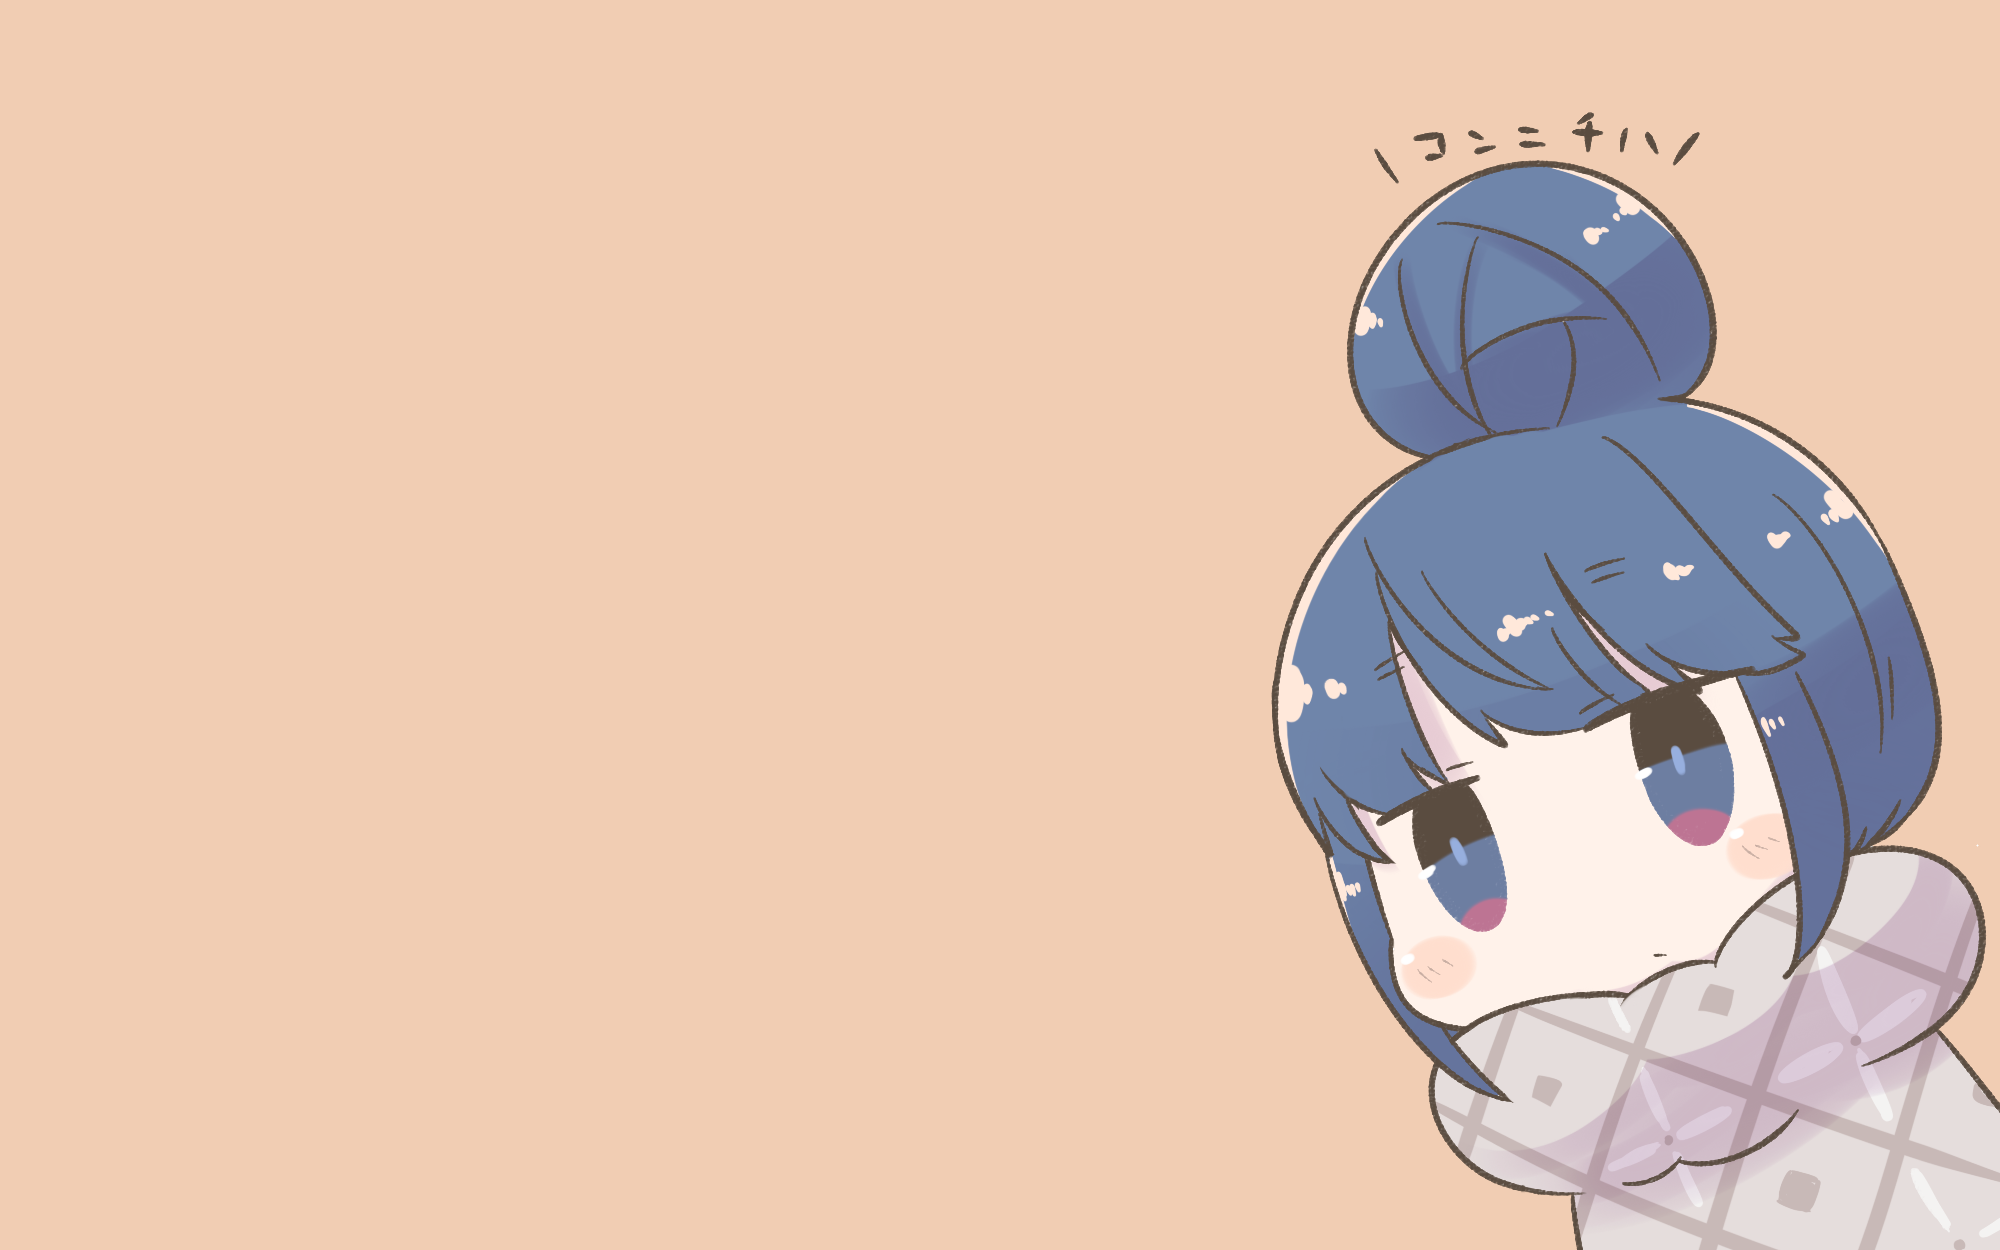

In [17]:
#解析二进制图片-base64编码
#有时候服务器返回的不是原始二进制流，而是 base64 编码的图片字符串（常见于一些 JSON 接口里嵌套返回图片的场景，比如 {"image": "iVBORw0KG..."}），需要先解码再处理
#此时解码方式如下
import base64,io
with open('../assets/images/905504.png','rb') as f:
    img_base64=base64.b64encode(f.read()).decode('utf-8')
response=requests.post('https://httpbin.org/post',json={"image":img_base64})

base64_str = json.loads(response.json()['data'])['image'] 

# base64 解码成原始二进制
image_bytes = base64.b64decode(base64_str)

# 用 PIL 打开
Image.open(io.BytesIO(image_bytes))

In [18]:
#当文件较大时，一次性把所有内容读入内存（response.content）可能占用过多资源，这时应使用流式下载，边接收边写入磁盘。
url = "https://httpbin.org/bytes/1048576"  # 模拟下载1MB数据
response = requests.get(url, stream=True)  # 关键：stream=True，不立即下载全部内容

with open("big_file.bin", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):  # 每次读取8KB
        if chunk:
            f.write(chunk)

print("下载完成")

try:
    os.remove('big_file.bin') #删除测试文件
except:
    pass

下载完成


## 3.8 示例-本地部署flask api服务与用户交互（base64图片传输）

按如下步骤操作：

1. 打开 Windows cmd，输入 `cd xxxx`（<当前文件夹路径>/example）
2. 输入 `python service.py`
3. 运行下一代码块

在上述过程中，我们首先启动了 `service.py` 中的本地 Flask 服务，该服务监听 `http://127.0.0.1`（localhost，本机地址）的 `8080` 端口，并定义了一个名为 `image_size` 的接口，可通过 `http://127.0.0.1:8080/image_size`访问。该接口只接受 **POST** 请求。该接口被调用时，将执行 `get_image_size()` 函数对客户端发送的 base64 编码图片进行解码并返回图片的长和宽。

In [4]:
import base64
import requests
with open('../assets/images/905504.png','rb') as f:
    img_base64=base64.b64encode(f.read()).decode('utf-8') #
response=requests.post('http://127.0.0.1:8080/image_size',json={"image":img_base64})
print(response.json())

{'height': 1250, 'width': 2000}


练习：尝试修改接口名、端口、和接口功能